# EDA Overview – Credit Card Fraud Detection
Author: Trần Đăng Khoa  
Role: Tổng quan & Cấu trúc dữ liệu  
## Mục tiêu
- Hiểu cấu trúc dataset
- Kiểm tra kích thước dữ liệu
- Kiểm tra missing values
- Phân tích sự mất cân bằng lớp (Fraud vs Legit)

In [5]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
# Load dữ liệu
df = pd.read_csv("../../data/creditcard_2023.csv")
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


Cột `id` là mã định danh giao dịch, không mang ý nghĩa dự đoán và sẽ được loại bỏ ở bước xây dựng mô hình.

In [8]:
# Kiểm tra kích thước dữ liệu
print("Số dòng và cột:", df.shape)

Số dòng và cột: (568630, 31)


## Tổng quan bộ dữ liệu

Bộ dữ liệu gồm **568.630 giao dịch** với **31 thuộc tính**.

- Mỗi dòng tương ứng với một giao dịch thẻ tín dụng.
- Các cột V1–V28 là các đặc trưng đã được ẩn danh (anonymized features).
- Cột `Class` là biến mục tiêu:
  - 0: Giao dịch hợp lệ
  - 1: Giao dịch gian lận

Đây là một bài toán phân loại nhị phân (Binary Classification).

In [9]:
# Kiểu dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     568630 non-nu

## Kiểu dữ liệu và cấu trúc

- Bộ dữ liệu gồm 568.630 dòng và 31 cột.
- Tất cả các cột đều có 568.630 giá trị non-null → không có giá trị thiếu (missing values).
- Dữ liệu bao gồm:
  - 29 cột kiểu float64 (các đặc trưng số liên tục V1–V28 và Amount)
  - 2 cột kiểu int64 (id và Class)

Cột `Class` là biến mục tiêu (target variable):
- 0: Giao dịch hợp lệ
- 1: Giao dịch gian lận

Như vậy, toàn bộ dữ liệu đều ở dạng số (numerical), thuận lợi cho việc huấn luyện các mô hình Machine Learning.

In [10]:
# Kiểm tra missing values
df.isnull().sum().sort_values(ascending=False)

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Kiểm tra giá trị thiếu (Missing Values)

Kết quả kiểm tra cho thấy tất cả các cột đều có 0 giá trị thiếu.

Như vậy, bộ dữ liệu không chứa missing values và không cần thực hiện các bước xử lý như:
- Xóa dữ liệu thiếu
- Điền giá trị thay thế (imputation)

Điều này giúp quá trình phân tích và xây dựng mô hình trở nên thuận lợi hơn.

In [11]:
# Kiểm tra trùng lặp
df.duplicated().sum()

np.int64(0)

## Kiểm tra dữ liệu trùng lặp

Kết quả cho thấy không có dòng dữ liệu nào bị trùng lặp.

Do đó, không cần thực hiện bước loại bỏ duplicate records.

In [12]:
# Kiểm tra phân bố Class (imbalance)
df["Class"].value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

In [ ]:
# Tính phần trăm
df["Class"].value_counts(normalize=True) * 100

Class
0    50.0
1    50.0
Name: proportion, dtype: float64

Biểu đồ thể hiện số lượng giao dịch của từng lớp.

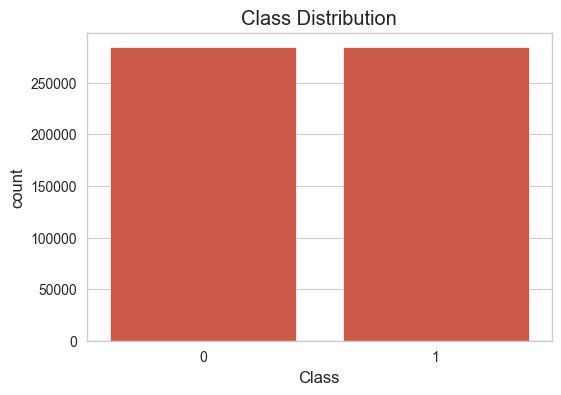

In [17]:
# Vẽ biểu đồ

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

Hai lớp Class 0 và Class 1 có số lượng bằng nhau.
Tỷ lệ mỗi lớp chiếm khoảng 50%.
Lưu ý: Dataset hiện tại đã được cân bằng (balanced). 
Do đó, không cần áp dụng các kỹ thuật xử lý mất cân bằng như SMOTE hoặc Undersampling.

## Phân phối các biến số (Histogram)

Biểu đồ histogram giúp quan sát phân bố giá trị của các biến số trong dataset.

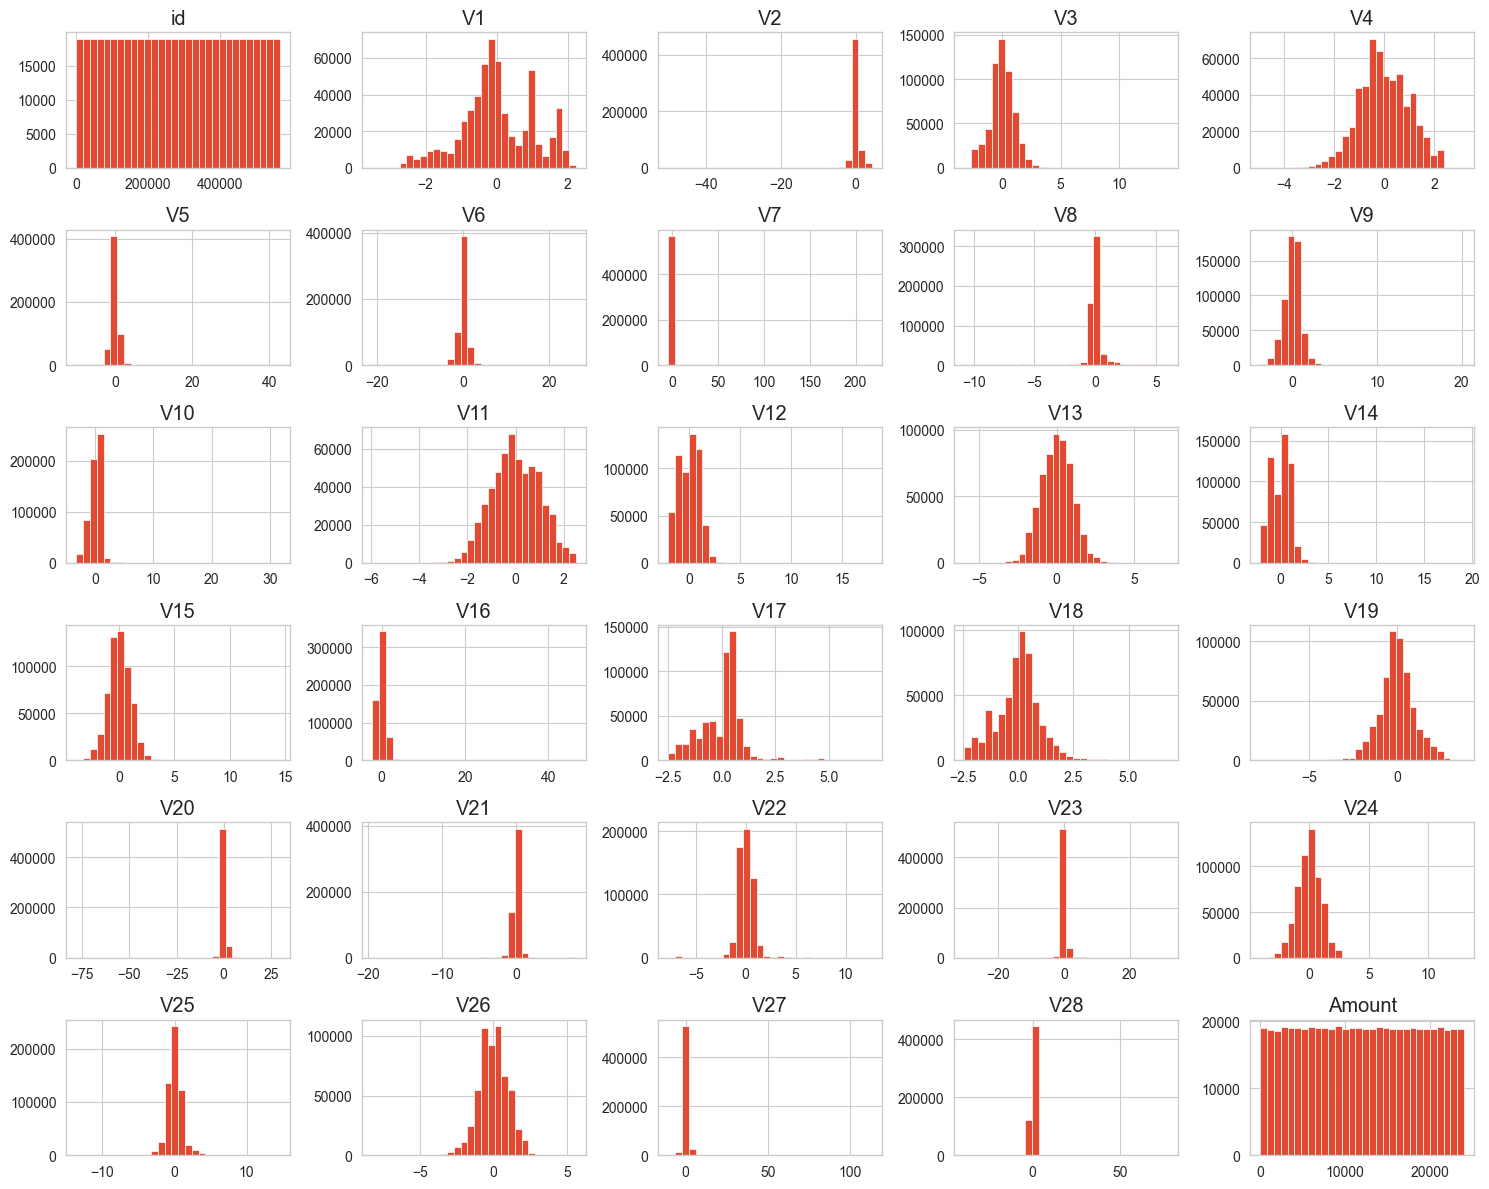

In [19]:
numeric_cols = df.drop("Class", axis=1).columns

df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

## Nhận xét Histogram các biến số

- Phần lớn các biến V1–V28 có phân phối gần chuẩn (normal distribution).
- Một số biến có hiện tượng lệch (skewed distribution).
- Biến Amount có phân phối lệch phải (right-skewed), cho thấy đa số giao dịch có giá trị nhỏ, một số ít có giá trị rất lớn.
- Điều này có thể cần chuẩn hóa hoặc log transformation khi xây dựng mô hình.

In [15]:
# Thống kê mô tả
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.118237e-17,-5.118237e-17,1.023647e-16,0.000000,2.559118e-17,2.559118e-17,0.000000,1.279559e-17,0.000000,...,1.279559e-17,1.599449e-18,5.598072e-18,-2.559118e-17,-4.478457e-17,-6.397796e-18,-2.559118e-17,3.198898e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222,-9.952786e+00,-2.111111e+01,-4.351839,-1.075634e+01,-3.751919,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-0.656020,-2.934955e-01,-4.458712e-01,-0.283533,-1.922572e-01,-0.568745,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-0.073762,8.108788e-02,7.871758e-02,0.233366,-1.145242e-01,0.092526,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,0.707005,4.397368e-01,4.977881e-01,0.525955,4.729905e-02,0.559262,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536,4.271689e+01,2.616840e+01,217.873038,5.958040e+00,20.270062,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


Thống kê mô tả dữ liệu

- Dataset có 568,630 quan sát cho mỗi biến.
- Các biến V1–V28 có giá trị trung bình (mean) xấp xỉ 0.
- Độ lệch chuẩn (std) của các biến này xấp xỉ 1.
- Điều này cho thấy các biến đã được chuẩn hóa (Standardized).

- Giá trị min và max cho thấy tồn tại một số giá trị biên lớn (outliers).
- Biến id tăng tuần tự từ 0 đến 568,629.
- Một số biến có giá trị min/max khá lớn, cho thấy tồn tại các giá trị biên (outliers). Điều này là bình thường trong dữ liệu giao dịch tài chính.
=> Nhìn chung dữ liệu đã được chuẩn hóa tốt và sẵn sàng cho bước xây dựng mô hình.

In [16]:
# Kiểm tra imbalance ratio
fraud_count = df["Class"].value_counts()[1]
normal_count = df["Class"].value_counts()[0]

print("Fraud ratio:", fraud_count / normal_count)

Fraud ratio: 1.0


Nghĩa là số Fraud = số Normal
Dataset của bạn đã được cân bằng (balanced)
## Kết luận EDA

- Dataset gồm 568,630 giao dịch và 31 thuộc tính.
- Không có giá trị thiếu hoặc trùng lặp.
- Các biến V1–V28 đã được chuẩn hóa (mean ≈ 0, std ≈ 1).
- Dataset hiện tại đã được cân bằng giữa hai lớp.

=> Dữ liệu sạch và sẵn sàng cho bước xây dựng mô hình phân loại.